<a href="https://colab.research.google.com/github/vishnuwadkar/Machine-Learning/blob/main/Neural%20Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [5]:
cols = ['fLength','fWidth','fSize','fConc','fConc1','fAsym','fM3Long','fM3Trans','FAlpha','fDist','class']
df = pd.read_csv("magic04.data", names = cols)

In [6]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,FAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [7]:
df["class"].unique()

array(['g', 'h'], dtype=object)

#### One Hot Encoding

In [8]:
df["class"] = (df["class"] == 'g').astype(int)

In [9]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,FAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


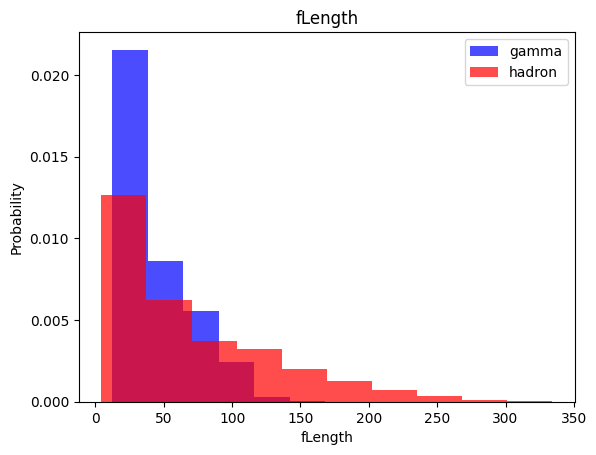

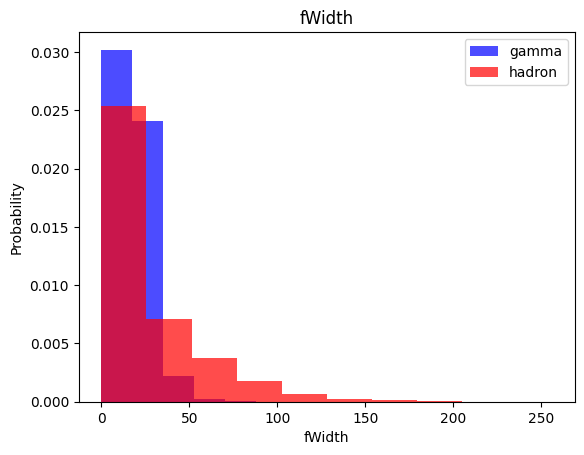

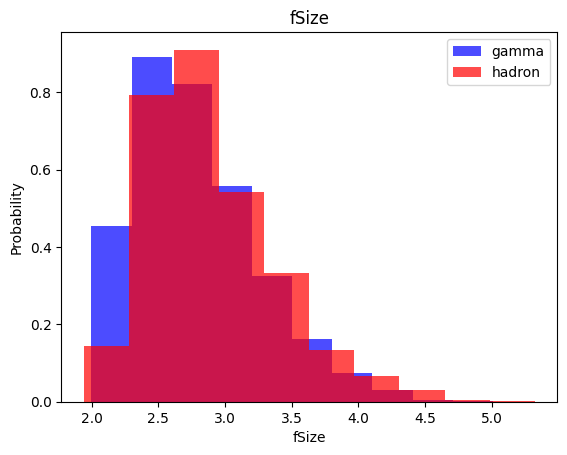

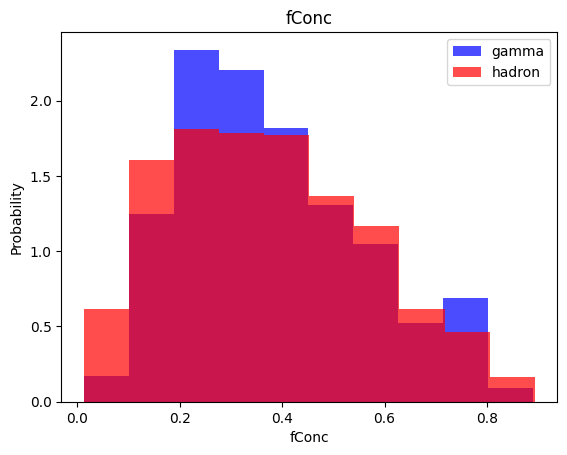

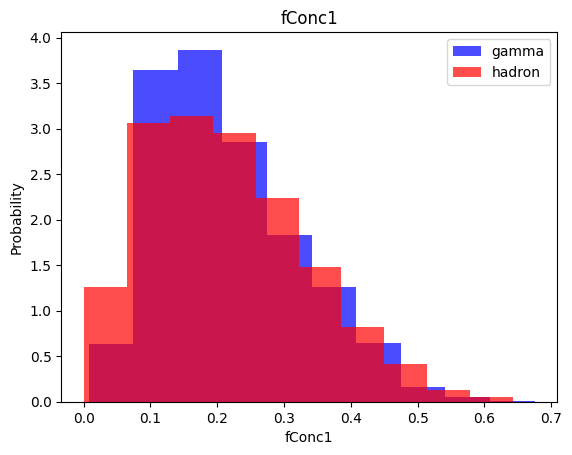

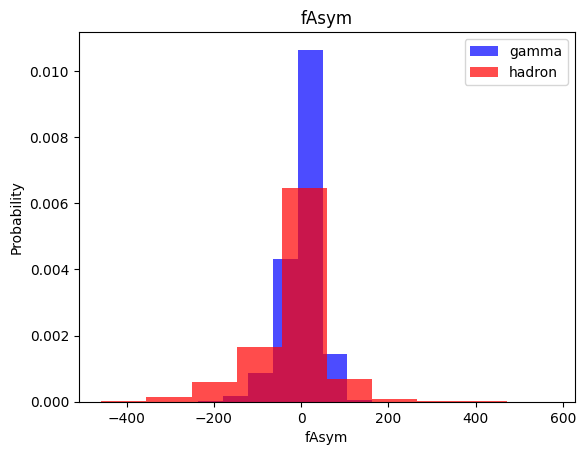

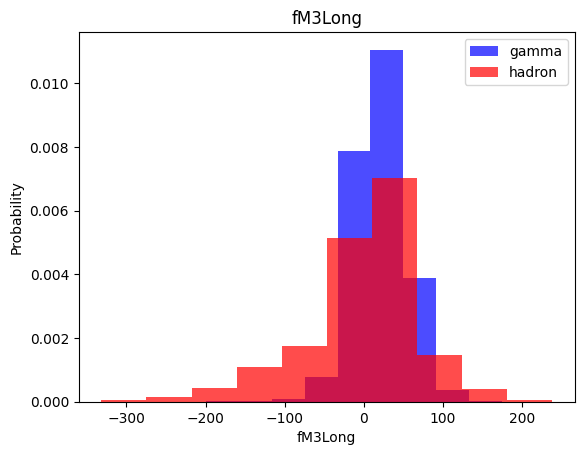

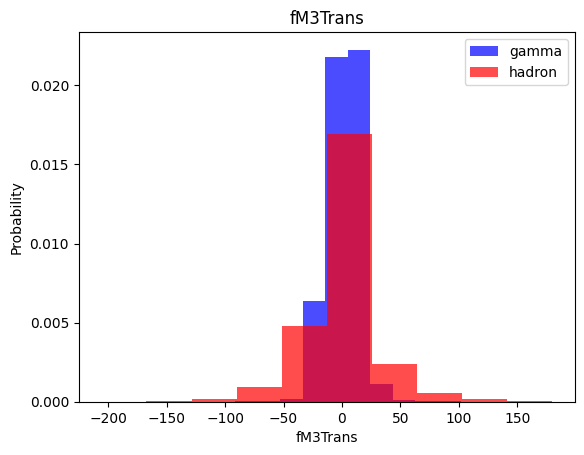

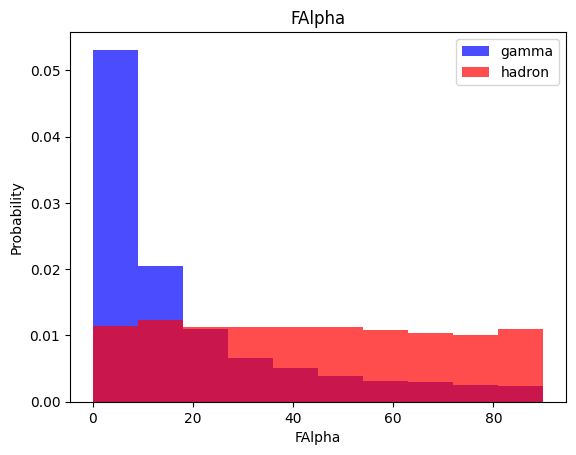

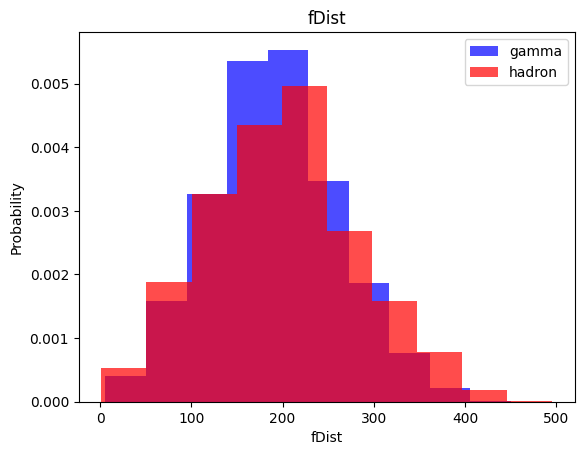

In [10]:
import matplotlib.pyplot as plt
for label in cols[:-1]:
  plt.hist(df[df['class']==1][label], color = 'blue', label = 'gamma', alpha = 0.7, density = True)
  plt.hist(df[df['class']==0][label], color = 'red', label = 'hadron', alpha = 0.7, density = True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()


### Training, Validation, Testing data

In [11]:
train, test, validation = np.split(df.sample(frac = 1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


### Scaling the data

In [12]:
def scale_dataset(dataframe, oversample = False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values
  scaler = StandardScaler()
  x = scaler.fit_transform(x)   #scaling old x values and updating the x as new

  if oversample:
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x, y)
  #horizontally stacking x and y
  data = np.hstack((x, np.reshape(y,(-1,1))))
  return data, x, y

In [13]:
train_df = pd.DataFrame(train, columns=cols)
train, x_train, y_train = scale_dataset(train_df, oversample = True)
validation, x_valid, y_valid = scale_dataset(train_df, oversample = False)
test, x_test, y_test = scale_dataset(train_df, oversample = False)

In [14]:
print(len(y_train))
print(sum(y_train == 1))
print(sum(y_train == 0))


14826
7413
7413


#### We need to oversample the hadron data

## NEURAL NETWORK


In [15]:
import tensorflow as tf

In [37]:
def train_model(x_train, y_train, num_nodes, dropout_prob, lr, batch_size, epoch):
  nn_model = tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes, activation = 'relu', input_shape = (10,)),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation = 'relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation = 'relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1, activation = 'sigmoid'),
  ])
  nn_model.compile(optimizer = tf.keras.optimizers.Adam(lr), loss = 'binary_crossentropy', metrics = ['accuracy'])

  history = nn_model.fit(x_train, y_train, epochs = epoch, batch_size = batch_size, validation_split = 0.2, verbose= 0)

  return nn_model, history

In [34]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (8, 2))
  ax1.plot(history.history['loss'],label = 'loss')
  ax1.plot(history.history['val_loss'],label = 'val_loss')
  ax1.set_xlabel('epoch')
  ax1.set_ylabel('Binary Cross Entropy')
  ax2.plot(history.history['accuracy'],label = 'accuracy')
  ax2.plot(history.history['val_accuracy'],label = 'val_accuracy')
  ax2.set_xlabel('epoch')
  ax2.set_ylabel('accuracy')
  plt.legend()
  plt.grid(True)
  plt.show()

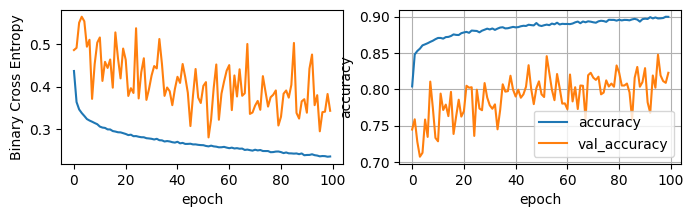

In [35]:
plot_history(history)

In [25]:
# history = nn_model.fit(x_train, y_train, epochs = 100, batch_size = 32, validation_split = 0.2 )

Epoch 1/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8039 - loss: 0.4366 - val_accuracy: 0.7444 - val_loss: 0.4858
Epoch 2/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8480 - loss: 0.3636 - val_accuracy: 0.7586 - val_loss: 0.4910
Epoch 3/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8527 - loss: 0.3463 - val_accuracy: 0.7276 - val_loss: 0.5501
Epoch 4/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8559 - loss: 0.3378 - val_accuracy: 0.7070 - val_loss: 0.5641
Epoch 5/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8605 - loss: 0.3310 - val_accuracy: 0.7124 - val_loss: 0.5534
Epoch 6/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8619 - loss: 0.3237 - val_accuracy: 0.7583 - val_loss: 0.4936
Epoch 7/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8634 - loss: 0.3202 - val_accuracy: 0.7343 - val_loss: 0.5099
Epoch 8/100
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8653 - loss: 0.3174 - val_accu

num_nodes = 16, dropout_prob = 0, lr = 0.01, batch_size = 32


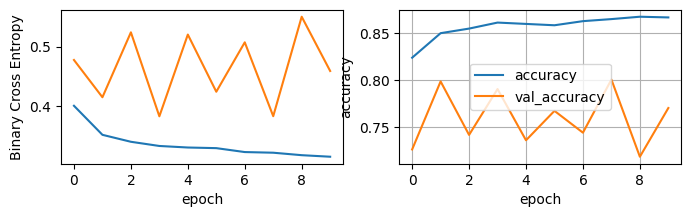

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8715 - loss: 0.3025
num_nodes = 16, dropout_prob = 0, lr = 0.01, batch_size = 64


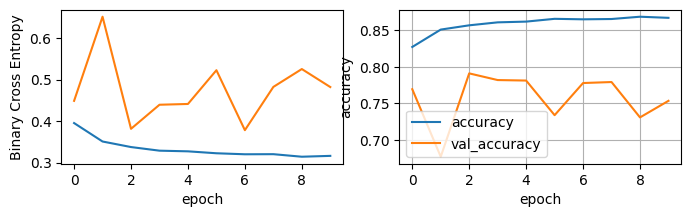

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8736 - loss: 0.3044
num_nodes = 16, dropout_prob = 0, lr = 0.01, batch_size = 128


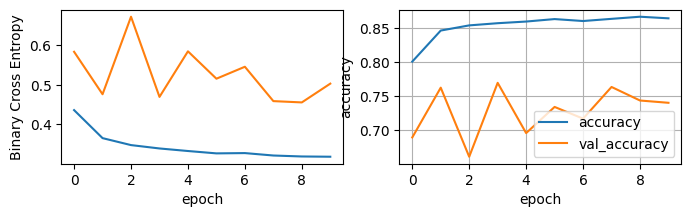

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8698 - loss: 0.3073
num_nodes = 16, dropout_prob = 0, lr = 0.005, batch_size = 32


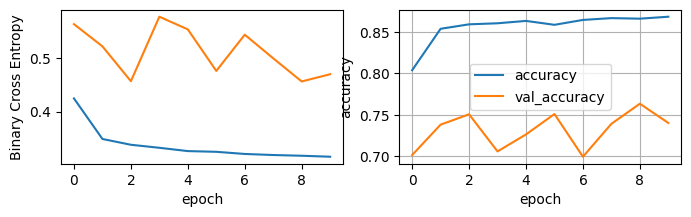

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8707 - loss: 0.3020
num_nodes = 16, dropout_prob = 0, lr = 0.005, batch_size = 64


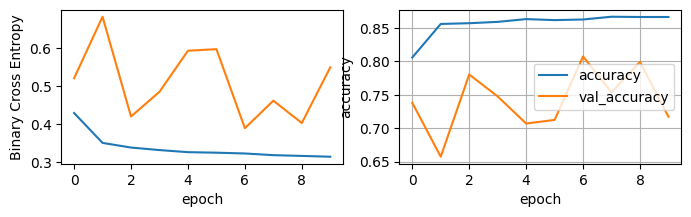

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8721 - loss: 0.3021
num_nodes = 16, dropout_prob = 0, lr = 0.005, batch_size = 128


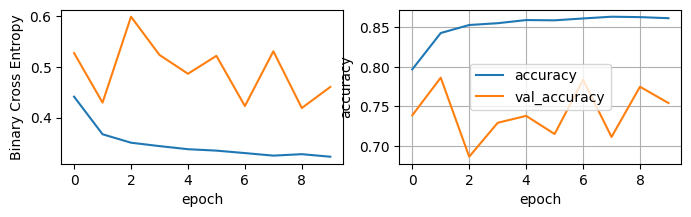

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8703 - loss: 0.3104
num_nodes = 16, dropout_prob = 0, lr = 0.001, batch_size = 32


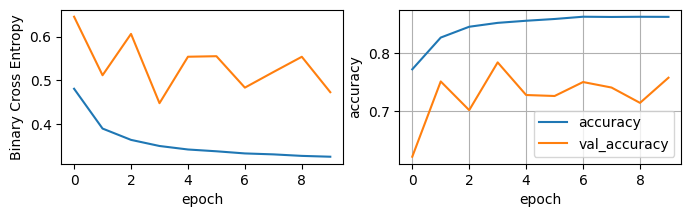

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8692 - loss: 0.3129
num_nodes = 16, dropout_prob = 0, lr = 0.001, batch_size = 64


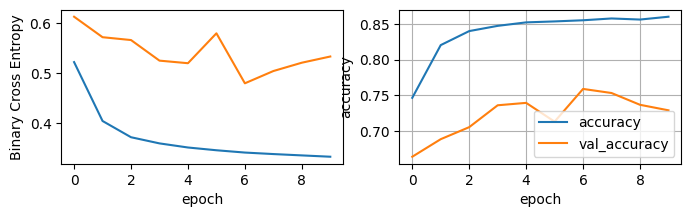

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8644 - loss: 0.3219
num_nodes = 16, dropout_prob = 0, lr = 0.001, batch_size = 128


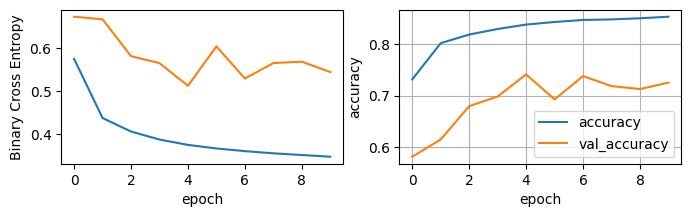

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8589 - loss: 0.3373
num_nodes = 16, dropout_prob = 0.2, lr = 0.01, batch_size = 32


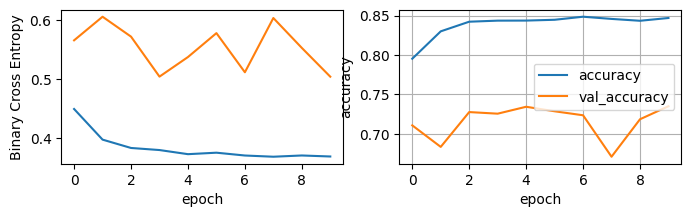

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8662 - loss: 0.3258
num_nodes = 16, dropout_prob = 0.2, lr = 0.01, batch_size = 64


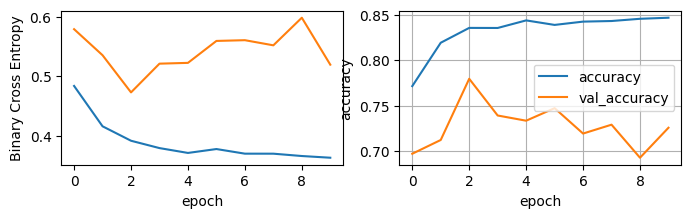

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.3283
num_nodes = 16, dropout_prob = 0.2, lr = 0.01, batch_size = 128


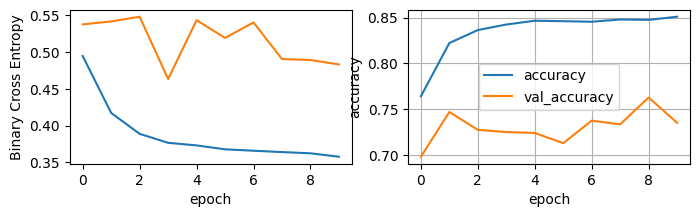

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8687 - loss: 0.3218
num_nodes = 16, dropout_prob = 0.2, lr = 0.005, batch_size = 32


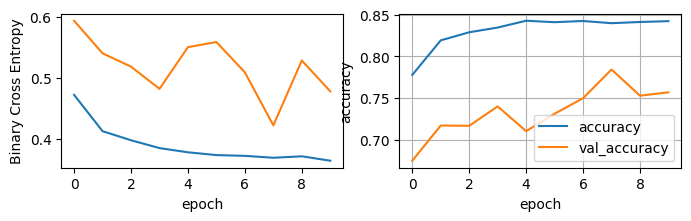

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8628 - loss: 0.3289
num_nodes = 16, dropout_prob = 0.2, lr = 0.005, batch_size = 64


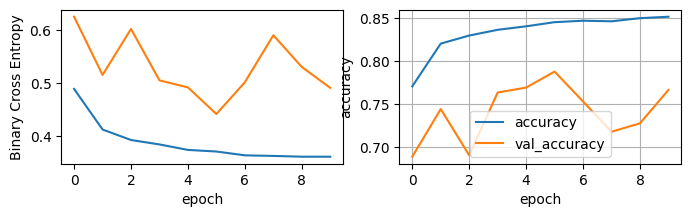

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8700 - loss: 0.3229
num_nodes = 16, dropout_prob = 0.2, lr = 0.005, batch_size = 128


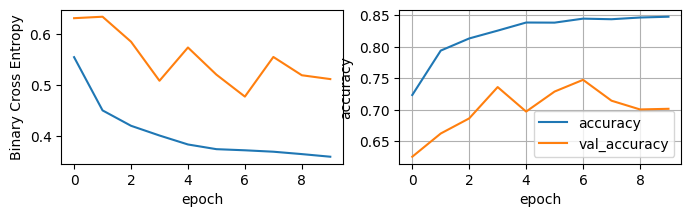

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8660 - loss: 0.3240
num_nodes = 16, dropout_prob = 0.2, lr = 0.001, batch_size = 32


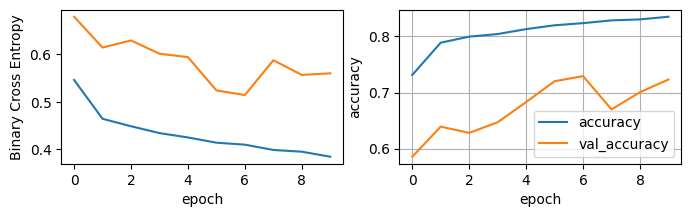

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8563 - loss: 0.3453
num_nodes = 16, dropout_prob = 0.2, lr = 0.001, batch_size = 64


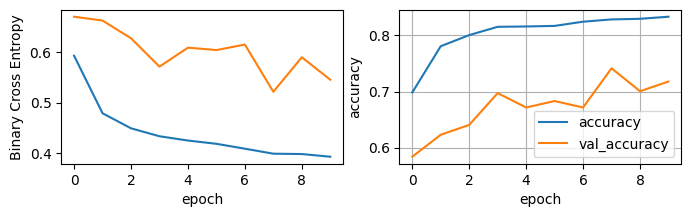

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8565 - loss: 0.3481
num_nodes = 16, dropout_prob = 0.2, lr = 0.001, batch_size = 128


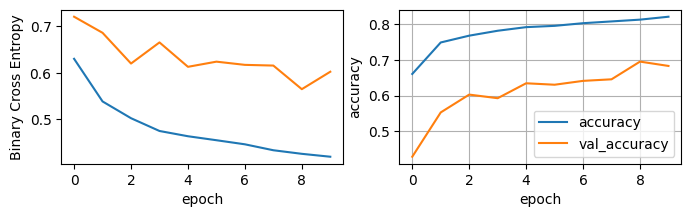

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8465 - loss: 0.3669
num_nodes = 32, dropout_prob = 0, lr = 0.01, batch_size = 32


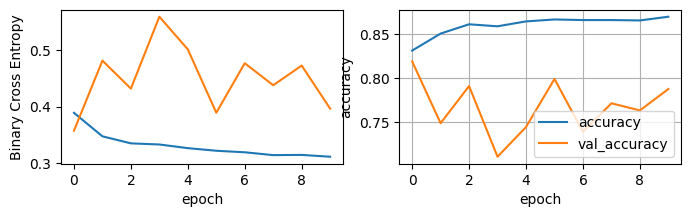

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8777 - loss: 0.2957
num_nodes = 32, dropout_prob = 0, lr = 0.01, batch_size = 64


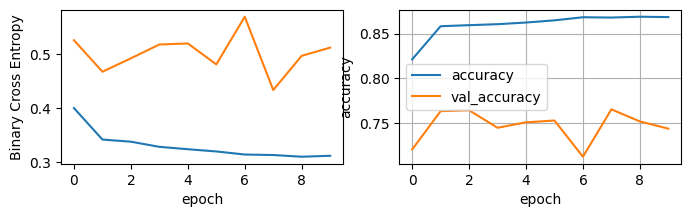

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8748 - loss: 0.2974
num_nodes = 32, dropout_prob = 0, lr = 0.01, batch_size = 128


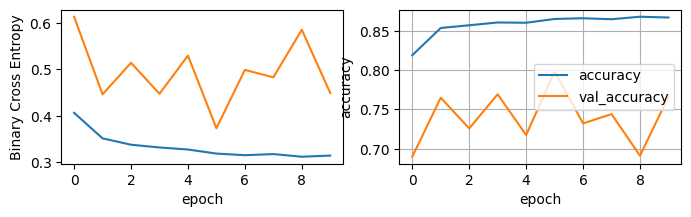

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8769 - loss: 0.3005
num_nodes = 32, dropout_prob = 0, lr = 0.005, batch_size = 32


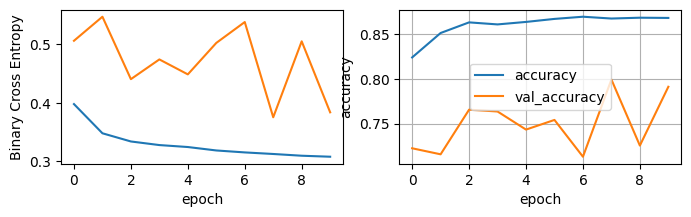

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8787 - loss: 0.3026
num_nodes = 32, dropout_prob = 0, lr = 0.005, batch_size = 64


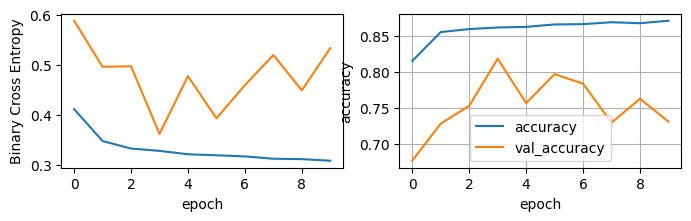

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8787 - loss: 0.2926
num_nodes = 32, dropout_prob = 0, lr = 0.005, batch_size = 128


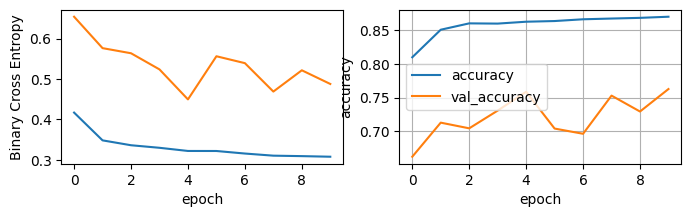

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8779 - loss: 0.2899
num_nodes = 32, dropout_prob = 0, lr = 0.001, batch_size = 32


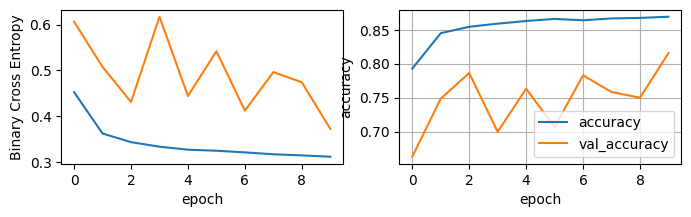

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8663 - loss: 0.3138
num_nodes = 32, dropout_prob = 0, lr = 0.001, batch_size = 64


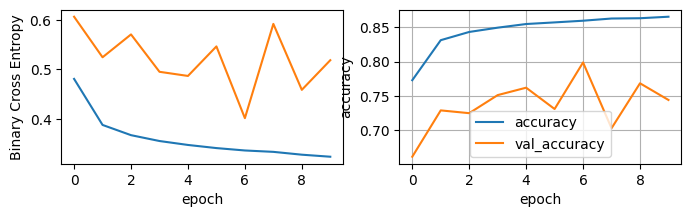

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8729 - loss: 0.3105
num_nodes = 32, dropout_prob = 0, lr = 0.001, batch_size = 128


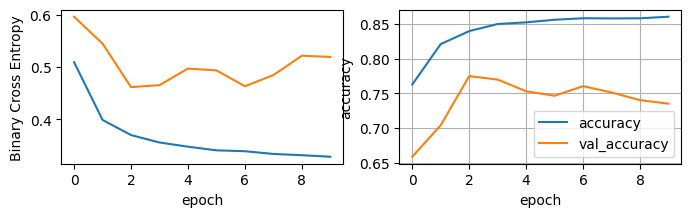

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8675 - loss: 0.3171
num_nodes = 32, dropout_prob = 0.2, lr = 0.01, batch_size = 32


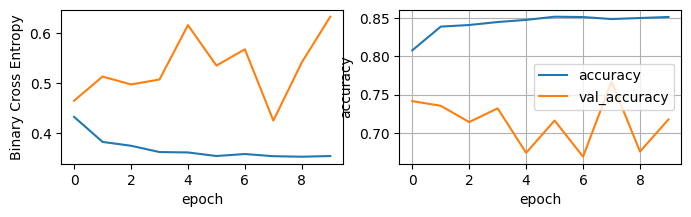

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8722 - loss: 0.3156
num_nodes = 32, dropout_prob = 0.2, lr = 0.01, batch_size = 64


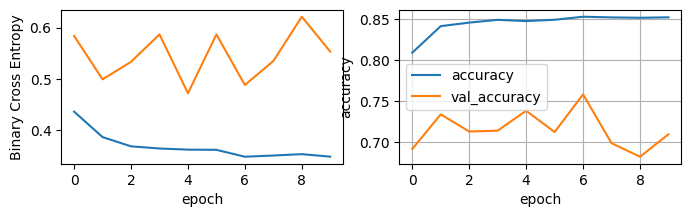

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8696 - loss: 0.3125
num_nodes = 32, dropout_prob = 0.2, lr = 0.01, batch_size = 128


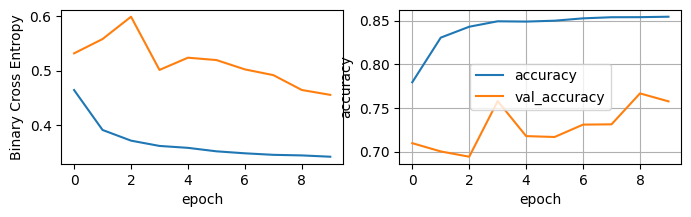

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8725 - loss: 0.3088
num_nodes = 32, dropout_prob = 0.2, lr = 0.005, batch_size = 32


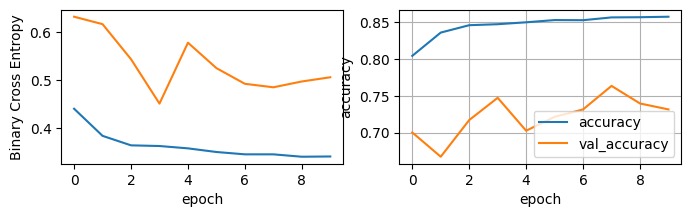

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8710 - loss: 0.3101
num_nodes = 32, dropout_prob = 0.2, lr = 0.005, batch_size = 64


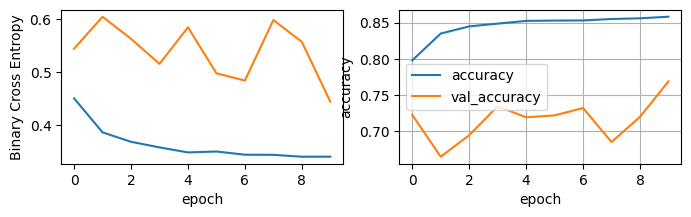

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8708 - loss: 0.3070
num_nodes = 32, dropout_prob = 0.2, lr = 0.005, batch_size = 128


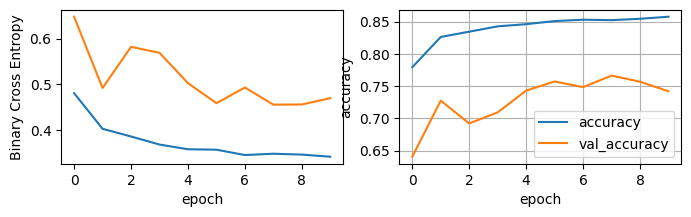

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8729 - loss: 0.3070
num_nodes = 32, dropout_prob = 0.2, lr = 0.001, batch_size = 32


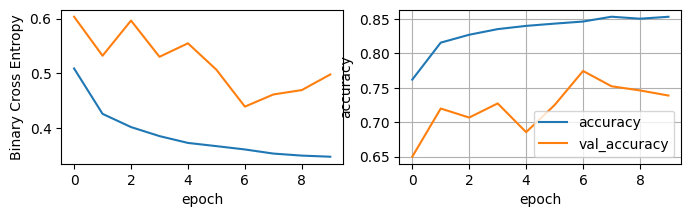

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8695 - loss: 0.3138
num_nodes = 32, dropout_prob = 0.2, lr = 0.001, batch_size = 64


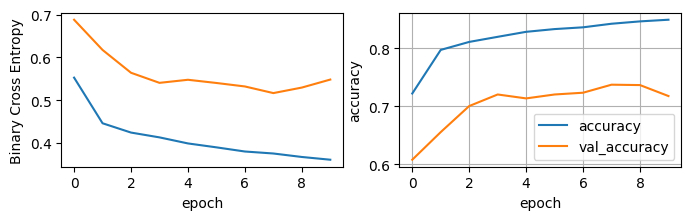

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8644 - loss: 0.3259
num_nodes = 32, dropout_prob = 0.2, lr = 0.001, batch_size = 128


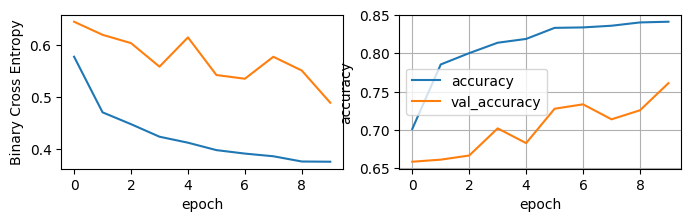

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8615 - loss: 0.3348
num_nodes = 64, dropout_prob = 0, lr = 0.01, batch_size = 32


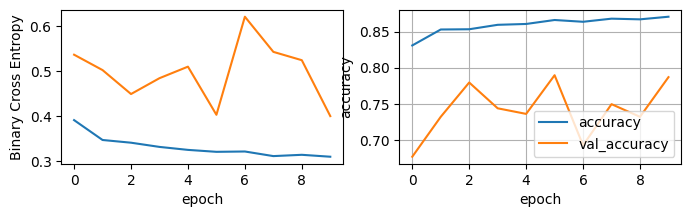

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8771 - loss: 0.2975
num_nodes = 64, dropout_prob = 0, lr = 0.01, batch_size = 64


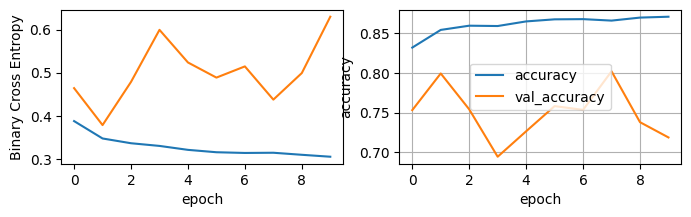

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8754 - loss: 0.3037
num_nodes = 64, dropout_prob = 0, lr = 0.01, batch_size = 128


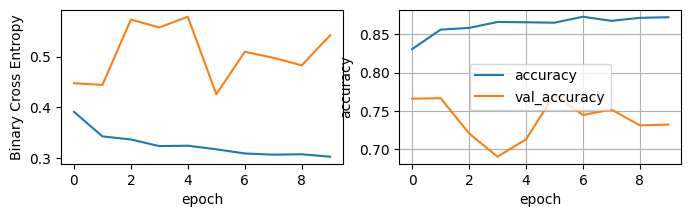

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8814 - loss: 0.2831
num_nodes = 64, dropout_prob = 0, lr = 0.005, batch_size = 32


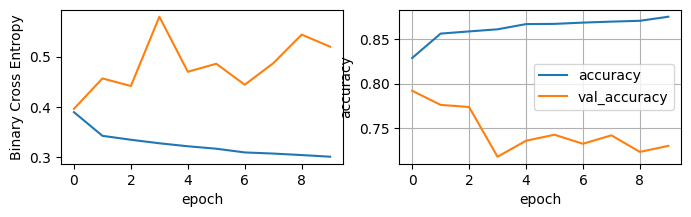

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8798 - loss: 0.2871
num_nodes = 64, dropout_prob = 0, lr = 0.005, batch_size = 64


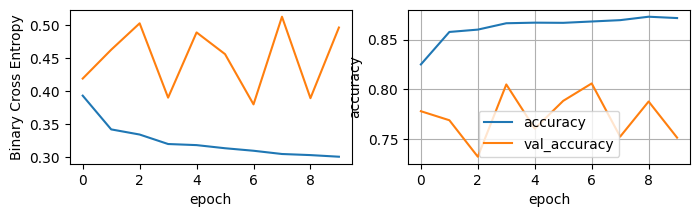

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8827 - loss: 0.2799
num_nodes = 64, dropout_prob = 0, lr = 0.005, batch_size = 128


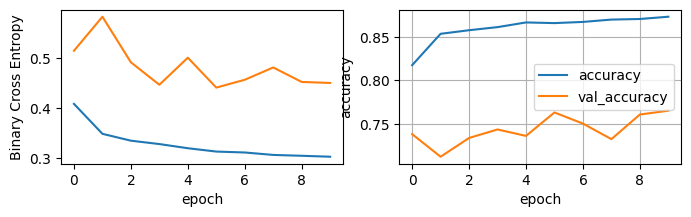

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8842 - loss: 0.2782
num_nodes = 64, dropout_prob = 0, lr = 0.001, batch_size = 32


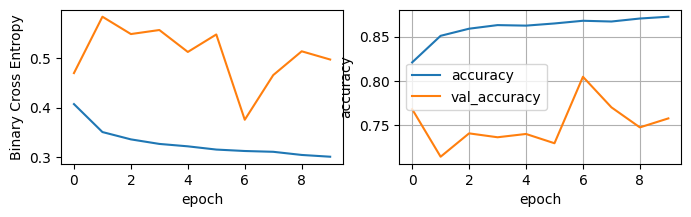

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8809 - loss: 0.2884
num_nodes = 64, dropout_prob = 0, lr = 0.001, batch_size = 64


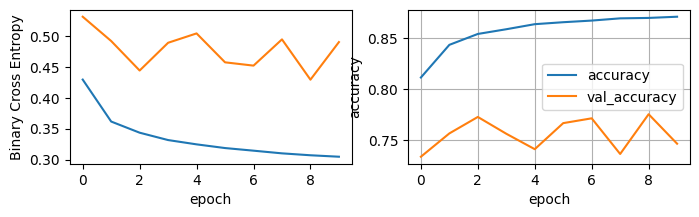

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8815 - loss: 0.2904
num_nodes = 64, dropout_prob = 0, lr = 0.001, batch_size = 128


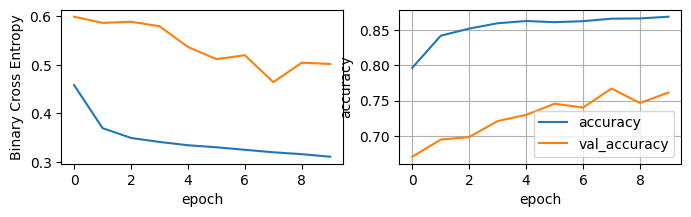

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8764 - loss: 0.3038
num_nodes = 64, dropout_prob = 0.2, lr = 0.01, batch_size = 32


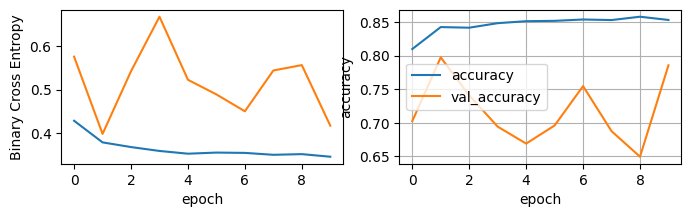

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8706 - loss: 0.3134
num_nodes = 64, dropout_prob = 0.2, lr = 0.01, batch_size = 64


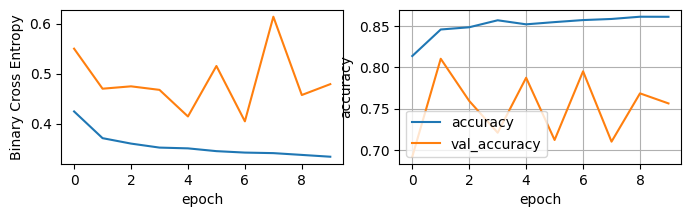

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8736 - loss: 0.2971
num_nodes = 64, dropout_prob = 0.2, lr = 0.01, batch_size = 128


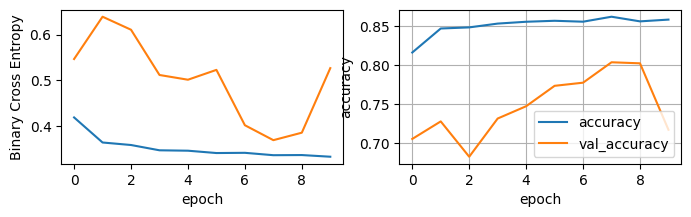

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8746 - loss: 0.3126
num_nodes = 64, dropout_prob = 0.2, lr = 0.005, batch_size = 32


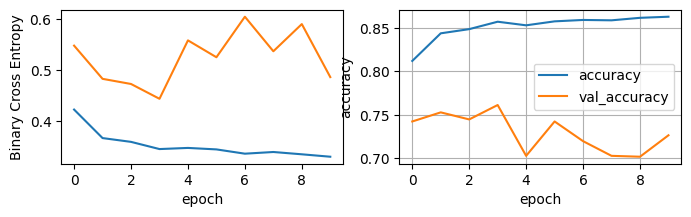

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8725 - loss: 0.2995
num_nodes = 64, dropout_prob = 0.2, lr = 0.005, batch_size = 64


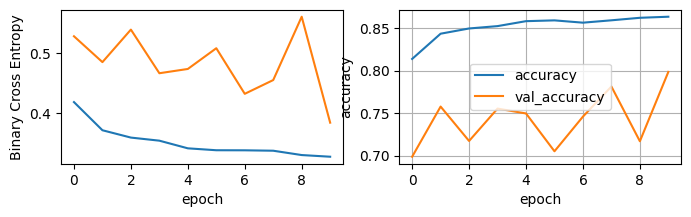

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8728 - loss: 0.3071
num_nodes = 64, dropout_prob = 0.2, lr = 0.005, batch_size = 128


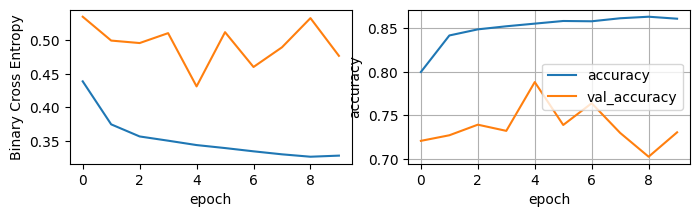

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8779 - loss: 0.2963
num_nodes = 64, dropout_prob = 0.2, lr = 0.001, batch_size = 32


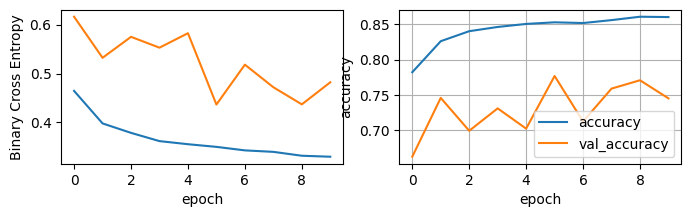

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8766 - loss: 0.2963
num_nodes = 64, dropout_prob = 0.2, lr = 0.001, batch_size = 64


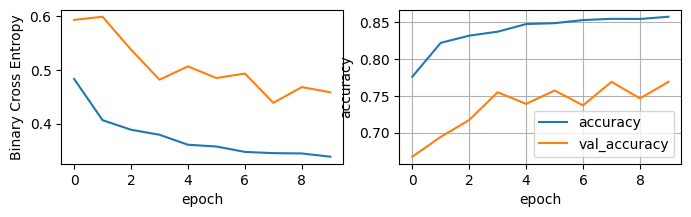

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8706 - loss: 0.3098
num_nodes = 64, dropout_prob = 0.2, lr = 0.001, batch_size = 128


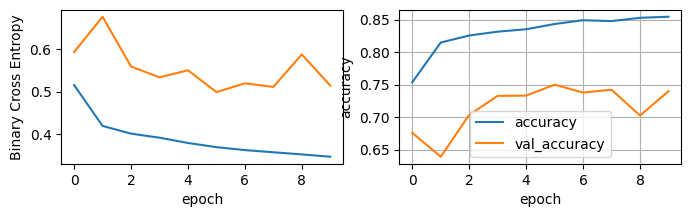

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8706 - loss: 0.3147


In [41]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 10
for num_nodes in [16, 32, 64]:
  for dropout_prob in [0, 0.2]:
    for lr in [0.01, 0.005, 0.001]:
      for batch_size in [32, 64, 128]:
        print(f'num_nodes = {num_nodes}, dropout_prob = {dropout_prob}, lr = {lr}, batch_size = {batch_size}')
        model, history = train_model(x_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
        plot_history(history)
        val_loss, val_accuracy = model.evaluate(x_valid, y_valid)
        if val_loss < least_val_loss:
          least_val_loss = val_loss
          least_loss_model = model

In [42]:
print(least_val_loss)
print(least_loss_model)


0.2781628370285034
<Sequential name=sequential_47, built=True>


In [44]:
y_pred = least_loss_model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)
print(y_pred)

357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[1 1 0 ... 1 1 1]


In [46]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.77      0.82      3999
           1       0.88      0.95      0.91      7413

    accuracy                           0.88     11412
   macro avg       0.89      0.86      0.87     11412
weighted avg       0.88      0.88      0.88     11412

